# 4.42 Four Ways to Measure a Coupling

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/docs%2Ftut%2F4-Analysis%2F4.42-Four-ways-to-measure-a-coupling.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=docs%2Ftut%2F4-Analysis%2F4.42-Four-ways-to-measure-a-coupling.ipynb)

> 💡 **What you need.** NumPy, SciPy and matplotlib. Runs in seconds. Second of five notebooks reproducing Molavi *et al.* [1]; [4.41](4.41-The-package-mode-on-paper.ipynb) introduced the device.

An electromagnetic simulator never hands you a coupling constant. It returns eigenfrequencies, fields, or a network response, with the junction replaced by *something* linear — an inductor, an open circuit, a port. The paper compares four ways of turning such output into the bare coupling $g$ between a qubit and a package mode:

| Method | Junction replaced by | Simulation | What gives $g$ |
|---|---|---|---|
| avoided crossing | variable inductor | eigenmode or driven | minimum splitting of two eigenfrequencies |
| energy participation (EPR) | fixed inductor, detuned | eigenmode | fraction of the package mode's energy in the junction |
| induced EMF | open circuit | eigenmode | voltage the package mode induces across the junction |
| impedance matrix | lumped port | driven | circuit parameters fitted to $Z(\omega)$ |

Before running any of them on a 3D model (notebook 4.45), this notebook runs all four on the circuit they all rest on: two coupled LC resonators. Here every quantity has an exact answer, so each method can be checked to the last digit, and its approximations can be seen one at a time.

**What you'll learn**

- what the bare coupling $g = g_C - g_L$ is, and how the capacitive and inductive parts combine;
- how each of the four methods extracts $g$, with the paper's formulas as code;
- which methods also give the *sign* of $g$, and why none can separate $g_C$ from $g_L$;
- how the Appendix D fit turns an impedance matrix back into a circuit.

In [ ]:
# In Colab, uncomment to install the dependencies of the whole series.
# Colab only (not needed locally): gmsh's Linux wheel needs system graphics libraries Colab lacks.
# !apt-get -qq update && apt-get -qq install -y libglu1-mesa libgl1 libxcursor1 libxft2 libxinerama1 libxfixes3 libxrender1 libxext6 libfontconfig1 > /dev/null
# !pip install -q "quantum-metal[skfem]" pymetis

In [1]:
import sys
import urllib.request
from pathlib import Path

# The solver code shared by tutorials 4.41-4.45 lives in docs/tut/resources/package_modes/.
RES = Path("../resources/package_modes")
if not (
    RES / "package_modes.py"
).exists():  # e.g. in Colab: fetch it next to the notebook
    RES = Path("package_modes")
    RES.mkdir(exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/qiskit-community/qiskit-metal/main/"
        "docs/tut/resources/package_modes/package_modes.py",
        RES / "package_modes.py",
    )
sys.path.insert(0, str(RES))

import package_modes as pm

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

TWO_PI = 2 * np.pi

## 1. The circuit

The equivalent circuit of the paper's Fig. 3: a package mode $m$ and a qubit $n$, each a capacitance in series with a geometric inductance $\delta L'$, shunted at its port by a lumped inductance $L'$. The coupling runs through a capacitance $C_c$ and a mutual inductance $M$. The junction is $L'_n$; the package-mode port is shunted by a tiny $L'_m$ that barely disturbs the mode. The values below are the ones the paper fits for the corner qubit (0,0) (Sec. III D), so this circuit *is* that qubit and its package mode.

Since the port nodes carry no capacitance, each shunt adds in series with its geometric inductance, and the circuit reduces to two resonators with capacitance and inductance matrices (Eq. A3)

$$\mathbf C = \begin{pmatrix} C_m + C_c & -C_c \\ -C_c & C_n + C_c\end{pmatrix}, \qquad
\mathbf L = \begin{pmatrix} L'_m + \delta L'_m & M \\ M & L'_n + \delta L'_n\end{pmatrix}.$$

In [2]:
p = pm.PAPER["zfit_q00"]
Cm, Cn, Cc = p["C_m"], p["C_n"], p["C_c"]
Lpm, dLm, dLn, M = p["Lp_m"], p["dL_m"], p["dL_n"], p["M"]


def matrices(Lpn):
    """C and L of the two-mode circuit for a junction inductance Lpn (henry)."""
    C = np.array([[Cm + Cc, -Cc], [-Cc, Cn + Cc]])
    L = np.array([[Lpm + dLm, M], [M, Lpn + dLn]])
    return C, L


Lpn = p["Lp_n"]  # 3.63 nH: the qubit sits about 0.4 GHz below the package mode
C, L = matrices(Lpn)
print("C (fF) =\n", C * 1e15)
print("L (nH) =\n", L * 1e9)

C (fF) =
 [[ 1.321e+02 -1.000e-01]
 [-1.000e-01  1.739e+02]]
L (nH) =
 [[ 4.571e+00 -3.400e-04]
 [-3.400e-04  3.950e+00]]


### Bare modes and the coupling

Writing the Hamiltonian in terms of node charges $Q$ and fluxes $\Phi$, $H = \tfrac12 Q^T\mathbf C^{-1}Q + \tfrac12\Phi^T\mathbf L^{-1}\Phi$, the diagonal elements define the *bare* resonators and the off-diagonal ones couple them (Appendix A):

$$\omega_k = \sqrt{(\mathbf L^{-1})_{kk}(\mathbf C^{-1})_{kk}},\quad
k_C = \frac{(\mathbf C^{-1})_{mn}}{\sqrt{(\mathbf C^{-1})_{mm}(\mathbf C^{-1})_{nn}}},\quad
k_L = -\frac{(\mathbf L^{-1})_{mn}}{\sqrt{(\mathbf L^{-1})_{mm}(\mathbf L^{-1})_{nn}}},\quad
g_{C,L} = \tfrac12 k_{C,L}\sqrt{\omega_m\omega_n}.$$

In the rotating-wave approximation the two channels combine into one exchange rate $g = g_C - g_L$. Both $g_C$ and $g_L$ scale as $\sqrt{\omega_n}$, so the $g$ that matters — the one the qubit would see *on resonance* with the mode — follows from the detuned values by Eq. (10),

$$g = \Big(g_C - g_L\,\frac{\omega_m}{\omega_n}\Big)\sqrt{\frac{\omega_m}{\omega_n}} .$$

In [3]:
bare = pm.circuit_couplings(C, L)
wm, wn = bare["w"]
g_exact = pm.g_on_resonance(bare["gC"], bare["gL"], wm, wn)
print(f"bare package mode  wm/2pi = {wm / TWO_PI / 1e9:.4f} GHz")
print(f"bare qubit         wn/2pi = {wn / TWO_PI / 1e9:.4f} GHz")
print(f"k_C = {bare['kC']:.3e},  k_L = {bare['kL']:.3e}")
print(
    f"g_C/2pi = {bare['gC'] / TWO_PI / 1e6:.3f} MHz, g_L/2pi = {bare['gL'] / TWO_PI / 1e6:.3f} MHz   "
    f"(paper: {p['gC'] / 1e6:.2f}, {p['gL'] / 1e6:.2f})"
)
print(
    f"on-resonance g/2pi = {g_exact / TWO_PI / 1e6:.3f} MHz   (paper: {p['g'] / 1e6:.2f} MHz)"
)

bare package mode  wm/2pi = 6.4768 GHz
bare qubit         wn/2pi = 6.0726 GHz
k_C = 6.598e-04,  k_L = -8.002e-05
g_C/2pi = 2.069 MHz, g_L/2pi = -0.251 MHz   (paper: 2.07, -0.25)
on-resonance g/2pi = 2.413 MHz   (paper: 2.42 MHz)


This is the reference value. The paper quotes 2.42 MHz from unrounded fit parameters; the rounded values it prints give 2.413 MHz. Note that $M < 0$ here, so $g_L < 0$ and the magnetic channel *adds* to the electric one.

## 2. Avoided crossing

Tune the qubit through the package mode by sweeping the junction inductance, and track the two normal-mode frequencies. Near resonance they repel; the smallest separation is $2|g|$ (Eq. 6). The exact normal modes of the circuit come from the eigenvalues of $\mathbf C^{-1/2}\mathbf L^{-1}\mathbf C^{-1/2}$ (Appendix A) — no rotating-wave approximation.

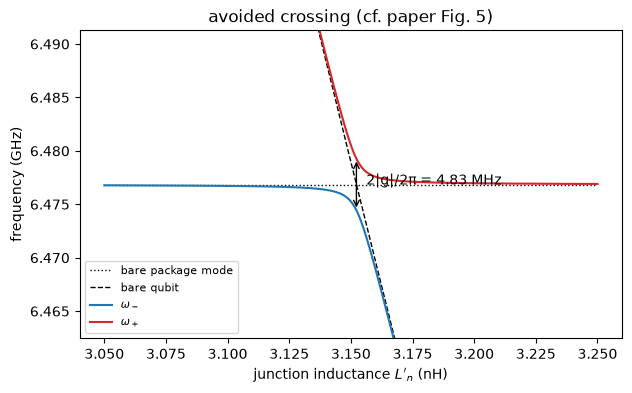

avoided crossing: |g|/2pi = 2.4131 MHz  at L'_n = 3.152 nH


In [4]:
Lsweep = np.linspace(3.05e-9, 3.25e-9, 801)
modes = np.array([pm.circuit_eigenfrequencies(*matrices(Lj)) for Lj in Lsweep]) / TWO_PI
split = modes[:, 1] - modes[:, 0]
k = np.argmin(split)
g_ac = split[k] / 2

# the bare frequencies along the sweep, for reference
bare_sweep = (
    np.array([pm.circuit_couplings(*matrices(Lj))["w"] for Lj in Lsweep]) / TWO_PI
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Lsweep * 1e9, bare_sweep[:, 0] / 1e9, "k:", lw=1, label="bare package mode")
ax.plot(Lsweep * 1e9, bare_sweep[:, 1] / 1e9, "k--", lw=1, label="bare qubit")
ax.plot(Lsweep * 1e9, modes[:, 0] / 1e9, color="tab:blue", label=r"$\omega_-$")
ax.plot(Lsweep * 1e9, modes[:, 1] / 1e9, color="tab:red", label=r"$\omega_+$")
ax.annotate(
    "",
    xy=(Lsweep[k] * 1e9, modes[k, 1] / 1e9),
    xytext=(Lsweep[k] * 1e9, modes[k, 0] / 1e9),
    arrowprops=dict(arrowstyle="<->"),
)
ax.text(
    Lsweep[k] * 1e9 + 0.004,
    modes[k].mean() / 1e9,
    f"2|g|/2π = {2 * g_ac / 1e6:.2f} MHz",
)
ax.set(
    xlabel="junction inductance $L'_n$ (nH)",
    ylabel="frequency (GHz)",
    ylim=(modes[k, 0] / 1e9 - 0.012, modes[k, 1] / 1e9 + 0.012),
    title="avoided crossing (cf. paper Fig. 5)",
)
ax.legend(fontsize=8, loc="lower left")
plt.show()
print(
    f"avoided crossing: |g|/2pi = {g_ac / 1e6:.4f} MHz  at L'_n = {Lsweep[k] * 1e9:.3f} nH"
)

The avoided crossing gives only $|g|$: the splitting is the same for either sign.

## 3. Energy participation

Now fix the junction so the qubit sits well below the mode (the paper uses about 0.2–0.4 GHz), solve for the package-like normal mode, and ask what fraction of its inductive energy sits in the junction (Eq. 7):

$$p_{mn} = \frac{E_{\rm junction}}{E_{m,\rm ind}} = \frac{\tfrac12 L'_n I_n^2}{\tfrac12 I^T\mathbf L\, I}.$$

A detuned qubit borrows a small piece of the mode, with an amplitude proportional to $g/(\omega_m-\omega_n)$ — so the participation is $\propto g^2$, and Eq. (8) inverts it:

$$g_C - g_L\frac{\omega_m}{\omega_n} = \frac{|\omega_m^2-\omega_n^2|}{2\sqrt{\omega_m\omega_n}}\sqrt{p_{mn}} .$$

In [5]:
def normal_modes(C, L):
    """Frequencies and node-flux vectors of the normal modes (classical, exact)."""
    w2, Phi = la.eig(
        la.inv(C) @ la.inv(L)
    )  # (C^-1 L^-1) V = w^2 V, fluxes share the same vectors
    order = np.argsort(w2.real)
    return np.sqrt(w2.real[order]), Phi.real[:, order]


w_modes, Phi = normal_modes(C, L)
package = np.argmax(
    np.abs(Phi[0]) / np.linalg.norm(Phi, axis=0)
)  # the mode living on node m
qubit = 1 - package
I = la.solve(L, Phi[:, package])  # branch currents of that mode
p_mn = 0.5 * Lpn * I[1] ** 2 / (0.5 * I @ L @ I)
wm_d, wn_d = w_modes[package], w_modes[qubit]  # what an eigenmode solver reports


def g_from_participation(p):
    """Eq. (8), then Eq. (10) to move to resonance."""
    lhs = abs(wm_d**2 - wn_d**2) / (2 * np.sqrt(wm_d * wn_d)) * np.sqrt(p)
    return lhs * np.sqrt(wm_d / wn_d)


sign = np.sign(
    I[1] / I[0]
)  # the relative sign of the junction current fixes the sign of g
g_epr = sign * g_from_participation(p_mn)
print(f"participation of the junction in the package mode: p = {p_mn:.3e}")
print(
    f"EPR: g/2pi = {g_epr / TWO_PI / 1e6:+.4f} MHz   (exact {g_exact / TWO_PI / 1e6:+.4f})"
)

participation of the junction in the package mode: p = 3.066e-05
EPR: g/2pi = +2.3133 MHz   (exact +2.4130)


EPR comes out 4% low, and the whole deficit has one source. Eq. (8) is derived for a qubit whose only inductance is the junction (Appendix B), but the qubit branch also carries its geometric inductance $\delta L'_n$ — 9% of the total here. The package mode stores energy in both, and counting only the junction's share undershoots $g$ by $\sqrt{L'_n/(L'_n+\delta L'_n)}$. Count the whole branch and the method is exact:

In [6]:
p_branch = 0.5 * (Lpn + dLn) * I[1] ** 2 / (0.5 * I @ L @ I)
print(
    f"EPR with the whole qubit branch: g/2pi = {sign * g_from_participation(p_branch) / TWO_PI / 1e6:+.4f} MHz"
)
print(
    f"sqrt(L'_n / (L'_n + dL'_n)) = {np.sqrt(Lpn / (Lpn + dLn)):.4f};  ratio found: {g_epr / g_exact:.4f}"
)

EPR with the whole qubit branch: g/2pi = +2.4131 MHz
sqrt(L'_n / (L'_n + dL'_n)) = 0.9586;  ratio found: 0.9587


EPR, like the induced EMF below, returns the *sign* of $g$ through the sign of the junction current relative to the mode. On a finite-element model the geometric inductance is not a separate element but part of the field around the junction, so the same shortfall appears there — the paper notes that EPR tends to come out slightly below the other methods, and notebook 4.45 returns to it.

## 4. Induced EMF

Open the junction ($L'_n \to \infty$). Now the qubit carries no current, its mode moves to zero frequency, and the package mode is alone. Its field still reaches across the junction gap and induces a voltage there — through the capacitive divider $C_c/(C_n+C_c)$ and through the mutual inductance (Eq. C1). With the mode normalized to energy $E_m$, the coupling follows from classical circuit theory (Eq. 11):

$$g = \frac{\omega_m V_{n,\rm open}}{2}\sqrt{\frac{C_n + C_c}{2E_m}} .$$

In [7]:
# Open junction: only the package branch carries current. Excite it with energy Em.
Em = 1.0  # joule
wm_open = 1 / np.sqrt(
    (Lpm + dLm) * (Cm + Cc * Cn / (Cc + Cn))
)  # Eq. (A15) with the qubit branch open
Vm = np.sqrt(
    2 * Em / (Cm + Cc * Cn / (Cc + Cn))
)  # peak voltage on the package capacitor node
Im = Vm / (wm_open * (Lpm + dLm))  # peak current in the package branch
V_open = (
    Cc / (Cn + Cc) * Vm - wm_open * M * Im
)  # capacitive divider minus the EMF of M (Eq. C1)
g_emf = wm_open * V_open / 2 * np.sqrt((Cn + Cc) / (2 * Em))
print(f"voltage across the open junction for 1 J in the mode: {V_open:.4e} V")
print(
    f"EMF: g/2pi = {g_emf / TWO_PI / 1e6:+.4f} MHz   (exact {g_exact / TWO_PI / 1e6:+.4f})"
)

voltage across the open junction for 1 J in the mode: 2.5269e+03 V
EMF: g/2pi = +2.4130 MHz   (exact +2.4130)


No qubit mode, no detuning, no sweep: one solution of the package mode gives every qubit's coupling at once, as long as each qubit's capacitance $C_n + C_c$ is known. That is why the paper calls this the most efficient method for a large array, and notebook 4.44 uses it for all 100 qubits. The voltage carries a sign, and so does $g$.

## 5. Impedance matrix

The last method treats the two junction positions as ports of a driven simulation and fits the circuit to the resulting impedance matrix. Here the "simulation" is the circuit itself, Eq. (12), sampled at 0.1 MHz from 6 to 7 GHz as in the paper.

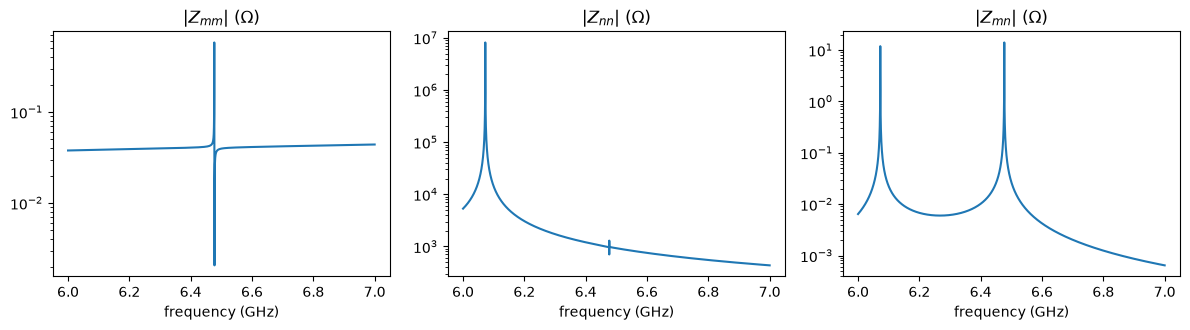

In [8]:
f = np.linspace(6e9, 7e9, 10001)
w = TWO_PI * f
Lp = np.diag([Lpm, Lpn])
dL = np.array([[dLm, M], [M, dLn]])
Z = pm.circuit_impedance(w, Lp, C, dL)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for a, (r, c_), name in zip(
    ax, ((0, 0), (1, 1), (0, 1)), ("$Z_{mm}$", "$Z_{nn}$", "$Z_{mn}$")
):
    a.semilogy(f / 1e9, np.abs(Z[:, r, c_]))
    a.set(title=f"|{name}| (Ω)", xlabel="frequency (GHz)")
plt.tight_layout()
plt.show()

Two poles — the qubit near 6.07 GHz and the package mode near 6.48 GHz. $Z_{mm}$ barely sees the package pole: its port is shunted by 1 pH, so a zero sits only ~0.6 MHz above the pole. That is why the frequency grid must be fine.

The fit follows Appendix D. A lossless network is a sum of poles plus a linear tail from everything above the band (Foster's form, Eq. D1/D4),

$$Z(\omega) = \sum_\mu \frac{2j\omega\,\omega_\mu}{\omega_\mu^2-\omega^2}R_\mu + j\omega\,\widetilde{\delta L} .$$

Each residue is a rank-one matrix $R_\mu = \sigma_\mu\sigma_\mu^T$, whose entries are the mode's zero-point flux at each port (Eq. D14). Stacking the $\sigma_\mu$ gives $\widetilde{\mathbf L}$ and $\widetilde{\mathbf C}$ (D7), and undoing the tail (D3) returns $\mathbf C$, $L'$ and $\delta L'$. `pm.fit_impedance` implements these steps.

In [9]:
fit = pm.fit_impedance(w, Z)
print(
    f"poles: {fit.poles / TWO_PI / 1e9} GHz, relative rms misfit {fit.rms_error:.1e}\n"
)
rows = [
    ("C_m (fF)", fit.C[0, 0] + fit.C[0, 1], Cm, 1e15),
    ("C_n (fF)", fit.C[1, 1] + fit.C[0, 1], Cn, 1e15),
    ("C_c (aF)", -fit.C[0, 1], Cc, 1e18),
    ("L'_m (pH)", fit.Lp[0, 0], Lpm, 1e12),
    ("L'_n (nH)", fit.Lp[1, 1], Lpn, 1e9),
    ("dL'_m (nH)", fit.dL[0, 0], dLm, 1e9),
    ("dL'_n (nH)", fit.dL[1, 1], dLn, 1e9),
    ("M (pH)", fit.dL[0, 1], M, 1e12),
]
print(f"{'':>11} {'fitted':>9} {'true':>9}")
for name, a, b, s in rows:
    print(f"{name:>11} {a * s:9.3f} {b * s:9.3f}")
gC_fit, gL_fit, g_z = fit.couplings()
print(
    f"\nimpedance matrix: g_C/2pi = {gC_fit / 1e6:.3f}, g_L/2pi = {gL_fit / 1e6:.3f}, g/2pi = {g_z / 1e6:+.4f} MHz"
)

poles: [6.07254746 6.47685364] GHz, relative rms misfit 2.0e-13

               fitted      true
   C_m (fF)   132.000   132.000
   C_n (fF)   173.800   173.800
   C_c (aF)   100.000   100.000
  L'_m (pH)     1.000     1.000
  L'_n (nH)     3.630     3.630
 dL'_m (nH)     4.570     4.570
 dL'_n (nH)     0.320     0.320
     M (pH)    -0.340    -0.340

impedance matrix: g_C/2pi = 2.069, g_L/2pi = -0.251, g/2pi = +2.4130 MHz


On noise-free data the fit returns the circuit exactly. With simulated data the individual $g_C$ and $g_L$ are not meaningful, the paper warns: moving the package port from one wall to another changes both while $g$ stays put. A distributed package mode has no unique "coupling capacitor" — only the combination $g$ is physical.

## 6. Side by side

            method  g/2pi (MHz)  rel. diff
  avoided crossing       2.4131      0.00%
               EPR       2.3133     -4.13%
       induced EMF       2.4130      0.00%
  impedance matrix       2.4130      0.00%
    exact (Eq. 10)       2.4130


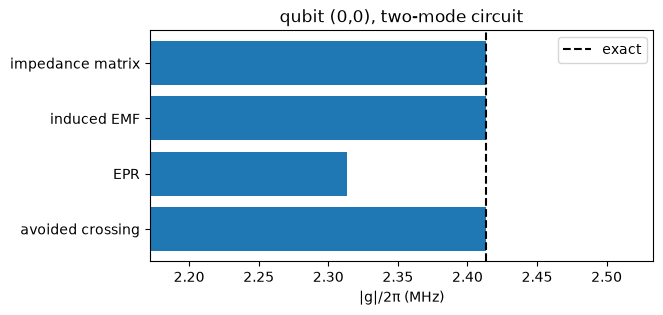

In [10]:
results = {
    "avoided crossing": g_ac
    * np.sign(g_exact),  # magnitude only; sign copied for the plot
    "EPR": g_epr / TWO_PI,
    "induced EMF": g_emf / TWO_PI,
    "impedance matrix": g_z,
}
ref = g_exact / TWO_PI
print(f"{'method':>18} {'g/2pi (MHz)':>12} {'rel. diff':>10}")
for name, g in results.items():
    print(f"{name:>18} {g / 1e6:12.4f} {(g - ref) / ref:10.2%}")
print(f"{'exact (Eq. 10)':>18} {ref / 1e6:12.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.barh(list(results), [abs(g) / 1e6 for g in results.values()], color="tab:blue")
ax.axvline(abs(ref) / 1e6, color="k", ls="--", label="exact")
ax.set(
    xlabel="|g|/2π (MHz)",
    xlim=(0.9 * abs(ref) / 1e6, 1.05 * abs(ref) / 1e6),
    title="qubit (0,0), two-mode circuit",
)
ax.legend()
plt.show()

Three methods are exact on this circuit; EPR is 4% low for the reason found in Sec. 3, and exact once the whole qubit branch is counted. (The avoided crossing agrees to 0.01%: the counter-rotating terms that the rotating-wave picture drops shift the splitting only at order $g^2/\omega$.) On a 3D model, discretization error adds to these — notebook 4.45 runs the same four methods through a finite-element solver.

## Where to go next

- **4.43 Mesh and solve the 10 × 10 processor** — build the device in Quantum Metal, mesh it with gmsh, and find the package eigenmode with an open-source Maxwell solver.
- Move the qubit closer to the mode: set `Lpn = 3.3e-9` and watch the EPR estimate drift as the perturbative assumption $|\omega_m-\omega_n|\gg|g|$ weakens.
- Flip the sign of `M` and see $g_C$ and $g_L$ now partly cancel.

## References

1. R. Molavi, E. Forati, Y. Zhang, A. R. Klots, J. Atalaya, B. W. Langley, D. A. Timucin, M. Nazari, G. Khan, Z. K. Minev, A. N. Korotkov, M. H. Devoret, "Extracting electromagnetic bare mode couplings in large superconducting quantum processors," [arXiv:2609.22442](https://arxiv.org/abs/2609.22442) (2026).
2. Z. K. Minev, Z. Leghtas, S. O. Mundhada, L. Christakis, I. M. Pop, M. H. Devoret, "Energy-participation quantization of Josephson circuits," *npj Quantum Inf.* **7**, 131 (2021). [doi:10.1038/s41534-021-00461-8](https://doi.org/10.1038/s41534-021-00461-8)
3. C. A. Balanis, *Advanced Engineering Electromagnetics*, 2nd ed. (Wiley, 2012) — LSM modes of a partially filled waveguide.
4. C. Geuzaine, J.-F. Remacle, "Gmsh: A 3-D finite element mesh generator with built-in pre- and post-processing facilities," *Int. J. Numer. Methods Eng.* **79**, 1309–1331 (2009). [doi:10.1002/nme.2579](https://doi.org/10.1002/nme.2579)
5. T. Gustafsson, G. D. McBain, "scikit-fem: A Python package for finite element assembly," *J. Open Source Softw.* **5**, 2369 (2020). [doi:10.21105/joss.02369](https://doi.org/10.21105/joss.02369)